# 🚀 Bidirectional Cross-Attention Fusion — Complete Pipeline
### Training + Evaluation + Single-Image Prediction

| Stage | What it does |
|---|---|
| **Training** | Train on `archive/` with manifest-based splits |
| **Manifest Eval** | Evaluate on test split of the manifest |
| **Holdout Eval** | Evaluate on `holdout_test/real` + `holdout_test/fake` |
| **Faceswap Eval** | Evaluate on `data/generated_faceswap/test` |
| **Combined** | Combined metrics across all test sets |
| **Predict** | Single-image prediction with visual overlay |

## STEP 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive mounted.')

Mounted at /content/drive
Google Drive mounted.


## STEP 2 — Install Dependencies

In [2]:
!pip install -q timm pillow scikit-learn tqdm matplotlib opencv-python

import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU! Go to Runtime > Change runtime type > T4 GPU')

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : Tesla T4


## STEP 2.5 — Extract `archive.zip` to Fast Local NVMe SSD

> **Recommended**: Run this once at the start of each Colab session to copy  
> `archive.zip` from Google Drive to the local SSD (~30–90 s).  
> Training then reads images at full NVMe speed (~10x faster than Drive).
>
> **Skip it?** No problem — STEP 8 includes `ensure_local_ssd()` which  
> auto-copies the data right before training starts if it isn't already there.

In [3]:
import os, shutil
from pathlib import Path

DRIVE_FOLDER_NAME = 'NEW_DATASET_DEEPFAKE'
DRIVE_ROOT = Path('/content/drive/MyDrive') / DRIVE_FOLDER_NAME
drive_zip = DRIVE_ROOT / 'archive.zip'
drive_archive = DRIVE_ROOT / 'archive'

LOCAL_ROOT = Path('/content/local_dataset')
LOCAL_ARCHIVE = LOCAL_ROOT / 'archive'

def auto_repair_structure():
    # Move real/fake into archive/ if extracted directly to local_dataset
    if (LOCAL_ROOT / 'real').exists() and (LOCAL_ROOT / 'fake').exists():
        LOCAL_ARCHIVE.mkdir(parents=True, exist_ok=True)
        for name in ['real', 'fake']:
            if (LOCAL_ROOT / name).exists() and not (LOCAL_ARCHIVE / name).exists():
                shutil.move(str(LOCAL_ROOT / name), str(LOCAL_ARCHIVE / name))
    # Fix double nesting (archive/archive/real)
    if (LOCAL_ARCHIVE / 'archive' / 'real').exists():
        for item in (LOCAL_ARCHIVE / 'archive').iterdir():
            if not (LOCAL_ARCHIVE / item.name).exists():
                shutil.move(str(item), str(LOCAL_ARCHIVE / item.name))
        shutil.rmtree(str(LOCAL_ARCHIVE / 'archive'), ignore_errors=True)
    # Move holdout_test and data to top-level if nested under archive/
    for f_name in ['holdout_test', 'data']:
        if not (LOCAL_ROOT / f_name).exists() and (LOCAL_ARCHIVE / f_name).exists():
            shutil.move(str(LOCAL_ARCHIVE / f_name), str(LOCAL_ROOT / f_name))

if (LOCAL_ARCHIVE / 'real').exists() and (LOCAL_ARCHIVE / 'fake').exists():
    auto_repair_structure()
    print(f'✅ Dataset is ready on local SSD at {LOCAL_ROOT}')
else:
    if LOCAL_ROOT.exists():
        print('🧹 Cleaning up old/partial local storage...')
        shutil.rmtree(LOCAL_ROOT, ignore_errors=True)
    LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

    if drive_zip.exists():
        zip_gb = drive_zip.stat().st_size / 1e9
        print(f'📦 Found archive.zip ({zip_gb:.2f} GB) on Google Drive!')
        print('🚀 Copying archive.zip to Colab NVMe SSD (~30 seconds)...')
        !cp "{drive_zip}" /content/

        print('⚡ Extracting all datasets (archive, holdout_test, data) to local SSD (~90 seconds)...')
        !unzip -q /content/archive.zip -d /content/local_dataset/

        auto_repair_structure()
        print(f'🎉 SUCCESS! All dataset folders extracted cleanly to: {LOCAL_ROOT}')
        if Path('/content/archive.zip').exists():
            Path('/content/archive.zip').unlink()
    elif drive_archive.exists():
        print(f'📁 Copying dataset folders from Drive to local SSD...')
        !cp -r "{drive_archive}" /content/local_dataset/
        if (DRIVE_ROOT / 'holdout_test').exists():
            !cp -r "{DRIVE_ROOT / 'holdout_test'}" /content/local_dataset/
        if (DRIVE_ROOT / 'data').exists():
            !cp -r "{DRIVE_ROOT / 'data'}" /content/local_dataset/
        auto_repair_structure()
        print(f'🎉 SUCCESS! Datasets copied to: {LOCAL_ROOT}')
    else:
        raise FileNotFoundError(f'❌ archive.zip not found on Drive at: {drive_zip}')


📦 Found archive.zip (16.64 GB) on Google Drive!
🚀 Copying archive.zip to Colab NVMe SSD (~30 seconds)...
⚡ Extracting all datasets (archive, holdout_test, data) to local SSD (~90 seconds)...
🎉 SUCCESS! All dataset folders extracted cleanly to: /content/local_dataset


## STEP 3 — Paths Configuration

In [4]:
from pathlib import Path

DRIVE_FOLDER_NAME = 'NEW_DATASET_DEEPFAKE'
PROJECT_ROOT      = Path('/content/drive/MyDrive') / DRIVE_FOLDER_NAME

LOCAL_ROOT_BASE = Path('/content/local_dataset')
LOCAL_ROOT = LOCAL_ROOT_BASE  # Initialize with base path

# Enhanced dynamic adjustment for LOCAL_ROOT
if LOCAL_ROOT_BASE.exists():
    found_nested_root = None
    for item in LOCAL_ROOT_BASE.iterdir():
        if item.is_dir():
            if (item / 'archive').is_dir() or \
               ((item / 'real').is_dir() and (item / 'fake').is_dir()):
                found_nested_root = item
                break

    if found_nested_root:
        print(f"Detected nested dataset root '{found_nested_root.name}' in {LOCAL_ROOT_BASE}.")
        print(f"Adjusting LOCAL_ROOT from {LOCAL_ROOT_BASE} to {found_nested_root} for dataset access.")
        LOCAL_ROOT = found_nested_root

ARCHIVE_ROOT      = LOCAL_ROOT / 'archive'
HOLDOUT_DIR       = LOCAL_ROOT / 'holdout_test'
FACESWAP_DIR      = LOCAL_ROOT / 'data' / 'generated_faceswap' / 'test'

OUTPUT_DIR        = PROJECT_ROOT / 'outputs'
MANIFEST_PATH     = OUTPUT_DIR   / 'manifest.csv'
EVAL_OUTPUT_DIR   = PROJECT_ROOT / 'eval_results'
EXTRA_IMAGE_ROOTS = [str(LOCAL_ROOT / 'data' / 'generated_faceswap')]

RESUME_CHECKPOINT = str(OUTPUT_DIR / 'cross_attention_v1' / 'last.pt')
CHECKPOINT_PATH   = OUTPUT_DIR / 'cross_attention_v1' / 'best.pt'

print('Checking paths...')
print(f'  Drive folder   : /content/drive/MyDrive/{DRIVE_FOLDER_NAME}')
print(f'  Local dataset  : {LOCAL_ROOT}')
print(f'  ARCHIVE_ROOT   : {ARCHIVE_ROOT}')
print()

checks = [
    ('archive/ (real/fake):', ARCHIVE_ROOT),
    ('holdout_test/:',        HOLDOUT_DIR),
    ('data/:',                LOCAL_ROOT / 'data'),
]
all_ok = True
for label, p in checks:
    ok = p.exists()
    print(f'  {"\u2705" if ok else "\u2139\ufe0f (optional)"} {label:<25} \u2192 {p}')
    if label.startswith('archive') and not ok:
        all_ok = False

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'  \u2705 outputs/              \u2192 {OUTPUT_DIR}  (auto-created)')
print(f'  \u2705 eval_results/         \u2192 {EVAL_OUTPUT_DIR}  (auto-created)')
print()

if all_ok:
    print('\u2705 Paths verified cleanly. Ready to run!')
else:
    # HARD STOP - required folder is missing
    raise FileNotFoundError(
        f'\n\u274c  Required archive/ folder NOT found at: {ARCHIVE_ROOT}\n'
        f'    Run STEP 2.5 to extract archive.zip first, then re-run this cell.'
    )

Detected nested dataset root 'dataset_complete' in /content/local_dataset.
Adjusting LOCAL_ROOT from /content/local_dataset to /content/local_dataset/dataset_complete for dataset access.
Checking paths...
  Drive folder   : /content/drive/MyDrive/NEW_DATASET_DEEPFAKE
  Local dataset  : /content/local_dataset/dataset_complete
  ARCHIVE_ROOT   : /content/local_dataset/dataset_complete/archive

  ✅ archive/ (real/fake):     → /content/local_dataset/dataset_complete/archive
  ✅ holdout_test/:            → /content/local_dataset/dataset_complete/holdout_test
  ✅ data/:                    → /content/local_dataset/dataset_complete/data
  ✅ outputs/              → /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs  (auto-created)
  ✅ eval_results/         → /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/eval_results  (auto-created)

✅ Paths verified cleanly. Ready to run!


In [5]:
if Path(RESUME_CHECKPOINT).exists():
    print(f"✅ Checkpoint found: {RESUME_CHECKPOINT}")
else:
    print(f"❌ Checkpoint NOT found at: {RESUME_CHECKPOINT}")
    print("Training will start from scratch.")

✅ Checkpoint found: /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/last.pt


In [6]:
# -- Hyperparameters -------------------------------------------------------
CONFIG = {
    'project': {
        'name':       'deepfake_bidirectional_cross_attention',
        'output_dir': str(OUTPUT_DIR),
        'run_name':   'cross_attention_v1',
    },
    'dataset': {
        'archive_root':      str(ARCHIVE_ROOT),
        'manifest_path':     str(MANIFEST_PATH),
        'rebuild_manifest':  True,
        'extra_image_roots': EXTRA_IMAGE_ROOTS,
        'split_seed':        42,
        'split_ratios':      {'train': 0.70, 'val': 0.15, 'test': 0.15},
    },
    'model': {
        'cnn_name':   'legacy_xception',
        'vit_name':   'vit_base_patch16_224',
        'pretrained': True,
        'fusion_dim': 512,
        'num_heads':  8,
        'dropout':    0.30,
    },
    'training': {
        'seed':                        42,
        'epochs':                      30,     # up from 25 - more room with warmup
        'freeze_backbone_epochs':       5,     # up from 2 - stabilise head before unfreezing
        'warmup_epochs':                2,     # NEW - linear LR warmup at start and after unfreeze
        'image_size':                 224,
        'batch_size':                  16,     # Safe memory for unfreezing backbones
        'gradient_accumulation_steps':  2,     # Effective batch_size = 32 (16*2)
        'num_workers':                  2,
        'lr_head':                  2e-4,      # down from 3e-4
        'lr_backbone':              1e-5,      # down from 3e-5 - finer backbone tuning
        'weight_decay':             1e-4,
        'label_smoothing':          0.05,      # NEW - reduces overconfidence
        'grad_clip_norm':            1.0,
        'amp':                       False,
        'channels_last':             True,
        'early_stopping_patience':      5,     # down from 7 - tighter budget
        'monitor_metric':        'roc_auc',
        'train_epoch_samples':       None,
    },
    'sampling':  {'balanced_train': True, 'balance_fake_methods': True},
    'imbalance': {'augment_real_extra': True, 'face_crop_train': False},
    'inference': {'face_crop': {'enabled': True, 'margin': 0.35, 'min_face_size': 48}},
}

THRESHOLD    = 0.5
BATCH_SIZE   = 16
FACE_WORKERS = 4

print('Config loaded.')

Config loaded.


## STEP 3.5 — Pre-Flight Check

Validates every critical path and setting **before** anything expensive runs.  
If any critical item is missing, execution stops immediately with a clear message.

In [7]:
# ============================================================
#  PRE-FLIGHT CHECK
#  Verifies all critical paths & settings before training.
#  CRITICAL failures raise an error and stop the notebook.
#  WARNINGS are non-blocking (e.g. optional eval sets).
# ============================================================
import torch as _torch
from pathlib import Path as _Path

_W = 68  # print width
_results = []
_critical_failed = False

def _chk(label, ok, detail='', critical=True):
    global _critical_failed
    if ok:
        tag = 'OK '
    elif critical:
        tag = 'FAIL'
        _critical_failed = True
    else:
        tag = 'WARN'
    _results.append((tag, label, str(detail)[:55]))

# ── 1. Google Drive mounted ───────────────────────────────────
_drive_ok = _Path('/content/drive/MyDrive').exists()
_chk('Google Drive mounted', _drive_ok,
     '/content/drive/MyDrive' if _drive_ok else 'Mount Drive first (STEP 1)')

# ── 2. Drive project folder ───────────────────────────────────
_proj_ok = _drive_ok and PROJECT_ROOT.exists()
_chk('Drive project folder', _proj_ok,
     PROJECT_ROOT if _proj_ok else f'Not found: {PROJECT_ROOT}')

# ── 3. Dataset source on Drive (zip or folder) ────────────────
_drive_zip  = PROJECT_ROOT / 'archive.zip'
_drive_arch = PROJECT_ROOT / 'archive'
_zip_ok  = _drive_ok and _drive_zip.exists()
_arch_ok = _drive_ok and _drive_arch.exists()
_src_ok  = _zip_ok or _arch_ok
if _zip_ok:
    _gb = _drive_zip.stat().st_size / 1e9
    _src_detail = f'archive.zip  ({_gb:.2f} GB)'
elif _arch_ok:
    _src_detail = f'archive/ folder'
else:
    _src_detail = f'NOT FOUND in {PROJECT_ROOT}'
_chk('Dataset source on Drive', _src_ok, _src_detail)

# ── 4. Local SSD data ─────────────────────────────────────────
_ssd_real = (ARCHIVE_ROOT / 'real').is_dir()
_ssd_fake = (ARCHIVE_ROOT / 'fake').is_dir()
_ssd_ok   = _ssd_real and _ssd_fake
if _ssd_ok:
    _n_real = sum(1 for p in (ARCHIVE_ROOT/'real').rglob('*') if p.is_file())
    _n_fake = sum(1 for p in (ARCHIVE_ROOT/'fake').rglob('*') if p.is_file())
    _ssd_detail = f'{_n_real:,} real + {_n_fake:,} fake images'
else:
    _ssd_detail = 'Not yet — STEP 8 will auto-copy from Drive'
_chk('Data on local SSD', _ssd_ok, _ssd_detail, critical=False)

# ── 5. Holdout test set (optional eval) ───────────────────────
_holdout_ok = HOLDOUT_DIR.exists()
_chk('Holdout test set (optional)', _holdout_ok,
     HOLDOUT_DIR if _holdout_ok else 'Not found — holdout eval will be skipped',
     critical=False)

# ── 6. Faceswap test set (optional eval) ──────────────────────
_faceswap_ok = FACESWAP_DIR.exists()
_chk('Faceswap test set (optional)', _faceswap_ok,
     FACESWAP_DIR if _faceswap_ok else 'Not found — faceswap eval will be skipped',
     critical=False)

# ── 7. Output directory writable ──────────────────────────────
try:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    _test_f = OUTPUT_DIR / '.preflight_write_test'
    _test_f.touch(); _test_f.unlink()
    _out_ok = True; _out_detail = OUTPUT_DIR
except Exception as _e:
    _out_ok = False; _out_detail = f'Write failed: {_e}'
_chk('Output dir writable', _out_ok, _out_detail)

# ── 8. Manifest path reachable ────────────────────────────────
_mf_ok = MANIFEST_PATH.exists() or MANIFEST_PATH.parent.exists()
_chk('Manifest path reachable', _mf_ok,
     MANIFEST_PATH if _mf_ok else f'Parent dir missing: {MANIFEST_PATH.parent}')

# ── 9. GPU available ──────────────────────────────────────────
_gpu_ok   = _torch.cuda.is_available()
_gpu_name = _torch.cuda.get_device_name(0) if _gpu_ok else 'NONE'
_chk('GPU available', _gpu_ok,
     _gpu_name if _gpu_ok else 'No GPU! Go Runtime > Change runtime type > T4 GPU',
     critical=False)

# ── 10. Sufficient disk space (>20 GB free) ───────────────────
import shutil as _shutil
_disk = _shutil.disk_usage('/')
_free_gb = _disk.free / 1e9
_disk_ok = _free_gb >= 20.0
_chk('Disk space (need >=20 GB)', _disk_ok,
     f'{_free_gb:.1f} GB free of {_disk.total/1e9:.1f} GB',
     critical=False)

# ── Print results ─────────────────────────────────────────────
TAG_ICONS = {'OK ': '\u2705', 'FAIL': '\u274c', 'WARN': '\u26a0\ufe0f '}
print('=' * _W)
print('  PRE-FLIGHT CHECK RESULTS')
print('=' * _W)
for _tag, _lbl, _det in _results:
    _icon = TAG_ICONS[_tag]
    _status = f'[{_tag}]' if _tag != 'OK ' else '     '
    print(f'  {_icon}  {_status}  {_lbl:<35}  {_det}')
print('=' * _W)

if _critical_failed:
    _failed = [lbl for tag, lbl, _ in _results if tag == 'FAIL']
    print()
    print('CRITICAL FAILURES:')
    for _f in _failed:
        print(f'  - {_f}')
    print()
    print('Fix the issues above and re-run this cell before continuing.')
    raise RuntimeError(
        'Pre-flight check failed: ' + ', '.join(_failed)
    )
else:
    _warn_n = sum(1 for tag, _, _ in _results if tag == 'WARN')
    _ok_n   = sum(1 for tag, _, _ in _results if tag == 'OK ')
    print(f'  {_ok_n} checks passed', end='')
    if _warn_n:
        print(f', {_warn_n} warning(s) (non-blocking).  Ready to continue!')
    else:
        print('.  All clear - ready to train!')

  PRE-FLIGHT CHECK RESULTS
  ✅         Google Drive mounted                 /content/drive/MyDrive
  ✅         Drive project folder                 /content/drive/MyDrive/NEW_DATASET_DEEPFAKE
  ✅         Dataset source on Drive              archive.zip  (16.64 GB)
  ✅         Data on local SSD                    31,949 real + 159,601 fake images
  ✅         Holdout test set (optional)          /content/local_dataset/dataset_complete/holdout_test
  ✅         Faceswap test set (optional)         /content/local_dataset/dataset_complete/data/generated_
  ✅         Output dir writable                  /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs
  ✅         Manifest path reachable              /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/man
  ✅         GPU available                        Tesla T4
  ✅         Disk space (need >=20 GB)            53.1 GB free of 120.9 GB
  10 checks passed.  All clear - ready to train!


## STEP 4 — Import All Modules

In [8]:
from __future__ import annotations
import logging, sys, os, random, json, math, shutil, time, io, csv
from datetime import datetime
from pathlib import Path
from collections import defaultdict, Counter
from concurrent.futures import ThreadPoolExecutor, as_completed
from dataclasses import dataclass

import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image, ImageDraw, ImageFont, UnidentifiedImageError
from tqdm import tqdm
import timm
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score,
)
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt

print('All imports successful.')

All imports successful.


## STEP 5 — Define All Helper Functions

In [9]:
# -- Logging ---------------------------------------------------------------
def configure_logging(level=logging.INFO):
    logging.basicConfig(level=level,
        format='%(asctime)s | %(levelname)s | %(message)s',
        handlers=[logging.StreamHandler(sys.stdout)], force=True)

def add_file_logger(log_file, level=logging.INFO):
    root = logging.getLogger()
    p = Path(log_file); p.parent.mkdir(parents=True, exist_ok=True)
    resolved = str(p.resolve())
    for h in root.handlers:
        if isinstance(h, logging.FileHandler) and h.baseFilename == resolved: return
    fh = logging.FileHandler(p, encoding='utf-8'); fh.setLevel(level)
    fh.setFormatter(logging.Formatter('%(asctime)s | %(levelname)s | %(message)s'))
    root.addHandler(fh)

configure_logging()

# -- Device -----------------------------------------------------------------
def get_device():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = True
        d = torch.device('cuda')
        logging.info(f'Using GPU: {torch.cuda.get_device_name(d)}')
        print(f'Using GPU: {torch.cuda.get_device_name(d)}')
        return d
    logging.warning('No GPU found. Training will be very slow on CPU!')
    print('WARNING: No GPU found. Training will be very slow on CPU!')
    return torch.device('cpu')

def ensure_dir(path): d=Path(path); d.mkdir(parents=True,exist_ok=True); return d
def resolve_path(path, base_dir=None):
    c=Path(path); return c if c.is_absolute() else (Path(base_dir) if base_dir else Path.cwd())/c

def seed_everything(seed):
    os.environ['PYTHONHASHSEED']=str(seed); random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

# -- Transforms -------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

class RandomJPEGCompression:
    def __init__(self, quality=(50,95)): self.quality=quality
    def __call__(self, img):
        q=random.randint(*self.quality); buf=io.BytesIO()
        img.save(buf,format='JPEG',quality=q); buf.seek(0)
        return Image.open(buf).copy()

def build_transforms(image_size, split):
    if split=='train':
        return transforms.Compose([
            # scale=(0.5,1.0) - keep faces large enough; was (0.25,1.0) which destroyed face region
            transforms.RandomResizedCrop(image_size,scale=(0.5,1.0),ratio=(0.75,1.33),
                interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomApply([transforms.ColorJitter(0.12,0.12,0.10,0.03)],p=0.35),
            transforms.RandomGrayscale(p=0.05),   # robustness to greyscale/B&W deepfakes
            transforms.RandomApply([RandomJPEGCompression()],p=0.40),
            transforms.RandomApply([transforms.GaussianBlur(3,sigma=(0.1,1.5))],p=0.20),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize(image_size+32,interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD),
    ])

def build_real_augment_transforms(image_size):
    return transforms.Compose([
        transforms.RandomResizedCrop(image_size,scale=(0.5,1.0),ratio=(0.75,1.33),
            interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.15,hue=0.03),
        transforms.RandomApply([RandomJPEGCompression()],p=0.40),
        transforms.RandomApply([transforms.GaussianBlur(3,sigma=(0.1,1.5))],p=0.30),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD),
    ])

# -- Safe Collate -----------------------------------------------------------
def safe_collate_fn(batch):
    """Filter None items (skipped missing/corrupt images) before collating.
    Returns None if the entire batch was empty (all images were missing).
    """
    batch = [item for item in batch if item is not None]
    if not batch:
        return None
    return torch.utils.data.dataloader.default_collate(batch)

# -- Local SSD Utilities ----------------------------------------------------
def _repair_ssd_structure(local_root):
    """Fix common zip-extraction structure mismatches on the local SSD."""
    local_root = Path(local_root)
    archive_dir = local_root / 'archive'
    # Case 1: real/fake extracted directly into local_root instead of archive/
    if (local_root / 'real').exists() and (local_root / 'fake').exists():
        archive_dir.mkdir(parents=True, exist_ok=True)
        for name in ['real', 'fake']:
            if (local_root / name).exists() and not (archive_dir / name).exists():
                shutil.move(str(local_root / name), str(archive_dir / name))
    # Case 2: double nesting (archive/archive/real)
    if (archive_dir / 'archive' / 'real').exists():
        for item in (archive_dir / 'archive').iterdir():
            if not (archive_dir / item.name).exists():
                shutil.move(str(item), str(archive_dir / item.name))
        shutil.rmtree(str(archive_dir / 'archive'), ignore_errors=True)
    # Case 3: holdout_test / data nested under archive/ instead of local_root/
    for folder in ['holdout_test', 'data']:
        if not (local_root / folder).exists() and (archive_dir / folder).exists():
            shutil.move(str(archive_dir / folder), str(local_root / folder))

def ensure_local_ssd(drive_root, local_root):
    """
    Guarantee ALL dataset folders are on Colab's fast local NVMe SSD.

    - Already there  : instant check, logs confirmation.
    - Not there yet  : auto-copies archive.zip from Drive and extracts.
    - Session restart: NVMe is wiped; this re-copies automatically.

    Call once at the top of STEP 8 (training) so training ALWAYS reads from SSD.
    Reading from NVMe is ~10x faster than reading from Google Drive.
    """
    import subprocess, time
    drive_root = Path(drive_root)
    local_root = Path(local_root)
    archive_dir = local_root / 'archive'

    # -- Fast path: data already on SSD ------------------------------------
    if (archive_dir / 'real').is_dir() and (archive_dir / 'fake').is_dir():
        n_real = sum(1 for p in (archive_dir/'real').rglob('*') if p.is_file())
        n_fake = sum(1 for p in (archive_dir/'fake').rglob('*') if p.is_file())
        msg = (f'Local SSD ready: {n_real:,} real + {n_fake:,} fake images'
               f'  [{local_root}]')
        logging.info(msg); print(msg)
        # Check optional folders
        for folder in ['holdout_test', 'data']:
            p = local_root / folder
            if p.exists():
                logging.info(f'  {folder}/ found on SSD')
            else:
                logging.warning(f'  {folder}/ NOT on SSD (optional, skipping eval for this set)')
        return local_root

    # -- Slow path: need to copy from Drive --------------------------------
    logging.warning('Dataset NOT on local SSD. Auto-copying from Drive now...')
    print('\nDataset not on local SSD. Copying from Drive (one-time ~30-90 s)...')
    print('(This happens automatically after every session restart)')

    drive_zip  = drive_root / 'archive.zip'
    drive_arch = drive_root / 'archive'
    local_root.mkdir(parents=True, exist_ok=True)
    t0 = time.time()

    if drive_zip.exists():
        gb = drive_zip.stat().st_size / 1e9
        print(f'  Found archive.zip ({gb:.2f} GB) on Drive.')
        print(f'  Step 1/2: Copying to SSD...')
        tmp = Path('/content/_archive_ssd_tmp.zip')
        t1 = time.time()
        subprocess.run(['cp', str(drive_zip), str(tmp)], check=True)
        elapsed_cp = time.time() - t1
        speed = gb * 1024 / max(elapsed_cp, 0.1)  # MB/s
        print(f'  Copy done in {elapsed_cp:.0f}s ({speed:.0f} MB/s).')
        logging.info(f'Copied archive.zip to SSD in {elapsed_cp:.0f}s ({speed:.0f} MB/s)')
        print(f'  Step 2/2: Extracting...')
        t2 = time.time()
        subprocess.run(['unzip', '-q', str(tmp), '-d', str(local_root)], check=True)
        tmp.unlink(missing_ok=True)
        print(f'  Extraction done in {time.time()-t2:.0f}s.')
        logging.info(f'Extraction done in {time.time()-t2:.0f}s')
    elif drive_arch.exists():
        print(f'  No zip found — copying archive/ folder from Drive...')
        subprocess.run(['cp', '-r', str(drive_arch), str(local_root / 'archive')], check=True)
        for folder in ['holdout_test', 'data']:
            src = drive_root / folder
            if src.exists():
                print(f'  Copying {folder}/...')
                subprocess.run(['cp', '-r', str(src), str(local_root / folder)], check=True)
    else:
        raise FileNotFoundError(
            f'No dataset found in Drive at {drive_root}\n'
            f'Expected: archive.zip  OR  archive/ folder.'
        )

    _repair_ssd_structure(local_root)
    total = time.time() - t0
    logging.info(f'Dataset ready on local SSD in {total:.0f}s total')
    print(f'\nDataset ready on local SSD. Total time: {total:.0f}s')
    return local_root

print('Utils, transforms, and SSD helpers defined.')

Utils, transforms, and SSD helpers defined.


In [10]:
# ── Face Crop ─────────────────────────────────────────────────────────────────
@dataclass(frozen=True)
class FaceCrop:
    image: Image.Image
    bbox: tuple | None
    num_faces_detected: int
    crop_source: str

def _detect_mediapipe(image, min_confidence=0.5):
    import mediapipe as mp
    rgb=np.asarray(image.convert('RGB')); h,w=rgb.shape[:2]
    with mp.solutions.face_detection.FaceDetection(
            model_selection=1, min_detection_confidence=min_confidence) as det:
        res=det.process(rgb)
    if not res.detections: return []
    boxes=[]
    for d in res.detections:
        bb=d.location_data.relative_bounding_box
        x=max(0,int(bb.xmin*w)); y=max(0,int(bb.ymin*h))
        bw=min(w-x,int(bb.width*w)); bh=min(h-y,int(bb.height*h))
        if bw>0 and bh>0: boxes.append((x,y,bw,bh))
    return sorted(boxes,key=lambda b:b[2]*b[3],reverse=True)

def _detect_haar(image, min_face_size=48):
    import cv2
    rgb=np.asarray(image.convert('RGB'))
    gray=cv2.equalizeHist(cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY))
    det=cv2.CascadeClassifier(str(Path(cv2.data.haarcascades)/'haarcascade_frontalface_default.xml'))
    faces=det.detectMultiScale(gray,1.08,5,minSize=(min_face_size,min_face_size))
    if len(faces)==0: return []
    return sorted([(int(x),int(y),int(w),int(h)) for x,y,w,h in faces],key=lambda b:b[2]*b[3],reverse=True)

def detect_faces(image, min_face_size=48):
    try:
        f=_detect_mediapipe(image)
        if f: return f
    except Exception: pass
    try: return _detect_haar(image,min_face_size)
    except Exception: return []

def _expand(box, size, margin):
    x,y,w,h=box; W,H=size; px,py=int(w*margin),int(h*margin)
    return max(0,x-px),max(0,y-py),min(W,x+w+px),min(H,y+h+py)

def crop_largest_face(image, margin=0.35, min_face_size=48, fallback_to_full_image=True):
    faces=detect_faces(image,min_face_size)
    if faces:
        bbox=_expand(faces[0],image.size,margin)
        return FaceCrop(image.crop(bbox),bbox,len(faces),'detected_face')
    if fallback_to_full_image: return FaceCrop(image,None,0,'full_image_fallback')
    raise RuntimeError('No face detected.')

def crop_all_faces(image, margin=0.35, min_face_size=48, fallback_to_full_image=True):
    faces=detect_faces(image,min_face_size)
    if faces:
        return [FaceCrop(image.crop(_expand(f,image.size,margin)),
                         _expand(f,image.size,margin),len(faces),'detected_face') for f in faces]
    if fallback_to_full_image: return [FaceCrop(image,None,0,'full_image_fallback')]
    raise RuntimeError('No face detected.')

print('Face crop defined.')

Face crop defined.


In [11]:
# ── Manifest ──────────────────────────────────────────────────────────────────
IMAGE_EXTENSIONS = {'.png','.jpg','.jpeg','.webp','.bmp'}
MANIFEST_FIELDS  = ['path','label','split','group_id','sample_id',
                    'video_id','source_id','target_id','pair_id','manipulation','frame_idx']

def _img_files(d): return sorted(p for p in d.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS)
def _fidx(p):
    try: return int(p.stem)
    except ValueError: return -1

def build_identity_components(fake_root):
    graph=defaultdict(set); ids=set()
    if fake_root.exists():
        for md in sorted(p for p in fake_root.iterdir() if p.is_dir()):
            for pd in sorted(p for p in md.iterdir() if p.is_dir()):
                if '_' not in pd.name: continue
                s,t=pd.name.split('_',1); ids.update([s,t]); graph[s].add(t); graph[t].add(s)
    v2g={}; seen=set()
    for vid in sorted(ids):
        if vid in seen: continue
        stack=[vid]; seen.add(vid); comp=[]
        while stack:
            cur=stack.pop(); comp.append(cur)
            for nb in sorted(graph[cur]):
                if nb not in seen: seen.add(nb); stack.append(nb)
        gid='component_'+'_'.join(sorted(comp))
        for m in comp: v2g[m]=gid
    return v2g

def assign_group_splits(group_ids,train_ratio,val_ratio,test_ratio,seed):
    ug=sorted(set(group_ids)); rng=random.Random(seed); rng.shuffle(ug)
    n=len(ug); nt=int(n*train_ratio); nv=int(n*val_ratio)
    return {g:('train' if i<nt else 'val' if i<nt+nv else 'test') for i,g in enumerate(ug)}

def assert_no_group_leakage(records):
    sbg=defaultdict(set)
    for r in records: sbg[r['group_id']].add(r['split'])
    bad={g:s for g,s in sbg.items() if len(s)>1}
    if bad: raise RuntimeError(f'Group leakage: {list(bad.items())[:5]}')

def build_manifest_records(archive_root,split_seed,split_ratios,extra_image_roots=None):
    ar=Path(archive_root).resolve(); rr=ar/'real'; fr=ar/'fake'
    if not rr.is_dir() or not fr.is_dir(): raise FileNotFoundError(f'Need real/ and fake/ in {ar}')
    v2g=build_identity_components(fr); gids=set(v2g.values())
    for d in sorted(p for p in rr.iterdir() if p.is_dir()): gids.add(v2g.get(d.name,f'real_{d.name}'))
    for md in sorted(p for p in fr.iterdir() if p.is_dir()):
        for pd in sorted(p for p in md.iterdir() if p.is_dir()):
            if '_' in pd.name: s,_=pd.name.split('_',1); gids.add(v2g.get(s,f'fake_{pd.name}'))
            else: gids.add(f'fake_{pd.name}')
    sbg=assign_group_splits(list(gids),float(split_ratios['train']),float(split_ratios['val']),float(split_ratios['test']),split_seed)
    rp=ar.parent; recs=[]
    for d in sorted(p for p in rr.iterdir() if p.is_dir()):
        vid=d.name; gid=v2g.get(vid,f'real_{vid}')
        for img in _img_files(d):
            recs.append({'path':img.relative_to(rp).as_posix(),'label':'0','split':sbg[gid],'group_id':gid,
                'sample_id':f'real/{vid}/{img.name}','video_id':vid,'source_id':vid,'target_id':'','pair_id':'',
                'manipulation':'real','frame_idx':str(_fidx(img))})
    for md in sorted(p for p in fr.iterdir() if p.is_dir()):
        man=md.name
        for pd in sorted(p for p in md.iterdir() if p.is_dir()):
            if '_' in pd.name: sid,tid=pd.name.split('_',1); gid=v2g.get(sid,f'fake_{pd.name}')
            else: sid,tid=pd.name,''; gid=f'fake_{pd.name}'
            for img in _img_files(pd):
                recs.append({'path':img.relative_to(rp).as_posix(),'label':'1','split':sbg[gid],'group_id':gid,
                    'sample_id':f'fake/{man}/{pd.name}/{img.name}','video_id':sid,'source_id':sid,'target_id':tid,
                    'pair_id':pd.name,'manipulation':man,'frame_idx':str(_fidx(img))})
    for er in extra_image_roots or []:
        root=Path(er).resolve()
        if not root.exists(): continue
        # Fix: Use rp (PROJECT_ROOT) as base for relative path instead of Path.cwd().resolve() (/content)
        # This prevents duplicating the drive path in the manifest records.
        pr=rp; dn=root.name
        for sp in ('train','val','test'):
            for cls,lbl in (('real','0'),('fake','1')):
                cr=root/sp/cls
                if not cr.is_dir(): continue
                for img in sorted(p for p in cr.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS):
                    try: rel=img.relative_to(pr).as_posix()
                    except ValueError: rel=str(img)
                    recs.append({'path':rel,'label':lbl,'split':sp,'group_id':f'{dn}_{sp}_{img.stem}',
                        'sample_id':f'{dn}/{sp}/{cls}/{img.name}','video_id':img.stem,'source_id':img.stem,
                        'target_id':'','pair_id':img.stem,'manipulation':dn if lbl=='1' else 'real',
                        'frame_idx':str(_fidx(img))})
    assert_no_group_leakage(recs)
    return recs

def write_manifest(records,output_path):
    op=Path(output_path); op.parent.mkdir(parents=True,exist_ok=True)
    with op.open('w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=MANIFEST_FIELDS); w.writeheader(); w.writerows(records)
    return op

def read_manifest(path):
    with Path(path).open('r',newline='',encoding='utf-8') as f: return list(csv.DictReader(f))

def summarize_manifest(records):
    s={}
    for sp in ('train','val','test'):
        sr=[r for r in records if r['split']==sp]
        s[sp]={'total':len(sr),'real':sum(r['label']=='0' for r in sr),'fake':sum(r['label']=='1' for r in sr)}
    return s

print('Manifest utilities defined.')

Manifest utilities defined.


In [12]:
# -- Dataset & Sampler -----------------------------------------------------
class ManifestImageDataset(Dataset):
    def __init__(self,manifest_path,split,root_dir,transform=None,real_transform=None,
                 use_face_crop=False,face_crop_margin=0.35,face_crop_min_size=48):
        self.root_dir=Path(root_dir); self.transform=transform; self.real_transform=real_transform
        self.use_face_crop=use_face_crop; self.face_crop_margin=face_crop_margin
        self.face_crop_min_size=face_crop_min_size
        with Path(manifest_path).open('r',newline='',encoding='utf-8') as f:
            self.records=[r for r in csv.DictReader(f) if r.get('split')==split]
        if not self.records: raise ValueError(f'No records for split={split!r}')
        logging.info(f'ManifestImageDataset [{split}]: {len(self.records)} records')

    def __len__(self): return len(self.records)

    def _resolve_image_path(self, rec_path):
        p1 = self.root_dir / rec_path
        if p1.exists(): return p1
        p_parts = Path(rec_path).parts
        if len(p_parts) > 1:
            p2 = self.root_dir / Path(*p_parts[1:])
            if p2.exists(): return p2
        p3 = self.root_dir / 'archive' / rec_path
        if p3.exists(): return p3
        return p1  # return p1 even if missing - caught in __getitem__

    def __getitem__(self,idx):
        rec=self.records[idx]; ip=self._resolve_image_path(rec['path'])
        # -- Missing image: log warning and skip (return None) --------------
        if not ip.exists():
            logging.warning(f'Image not found - skipping: {ip}')
            return None
        # -- Corrupt image: log warning and skip ----------------------------
        try:
            with Image.open(ip) as img: img=img.convert('RGB')
        except Exception as e:
            logging.warning(f'Corrupt image - skipping: {ip} | {e}')
            return None
        if self.use_face_crop:
            try: img=crop_largest_face(img,self.face_crop_margin,self.face_crop_min_size).image
            except Exception: pass
        tf=self.real_transform if rec['label']=='0' and self.real_transform else self.transform
        if tf: img=tf(img)
        return img,torch.tensor(float(rec['label']),dtype=torch.float32),rec

def build_balanced_sampler(dataset,balance_fake_methods=True,num_samples=None):
    labels=[r['label'] for r in dataset.records]
    rc=sum(l=='0' for l in labels); fc=sum(l=='1' for l in labels)
    if not rc or not fc: raise ValueError('Need both real and fake samples.')
    mc=Counter(r['manipulation'] for r in dataset.records if r['label']=='1'); nm=max(len(mc),1)
    weights=[]
    for r in dataset.records:
        if r['label']=='0': weights.append(0.5/rc)
        elif balance_fake_methods: weights.append(0.5/nm/mc[r['manipulation']])
        else: weights.append(0.5/fc)
    ns=num_samples or len(dataset)
    return WeightedRandomSampler(torch.DoubleTensor(weights),ns,replacement=True)

print('Dataset defined cleanly.')

Dataset defined cleanly.


## STEP 6 — Define Model

In [13]:
class BidirectionalCrossAttentionFusion(nn.Module):
    """
    CNN spatial tokens (49) attend over ViT patch tokens (196) and vice versa.
    Both enriched sequences are mean-pooled and concatenated → [B, fusion_dim*2]
    """
    def __init__(self,cnn_dim,vit_dim,fusion_dim,num_heads=8,dropout=0.30):
        super().__init__()
        self.cnn_proj=nn.Sequential(nn.LayerNorm(cnn_dim),nn.Linear(cnn_dim,fusion_dim),nn.GELU(),nn.Dropout(dropout))
        self.vit_proj=nn.Sequential(nn.LayerNorm(vit_dim),nn.Linear(vit_dim,fusion_dim),nn.GELU(),nn.Dropout(dropout))
        self.cnn_to_vit=nn.MultiheadAttention(fusion_dim,num_heads,dropout=dropout,batch_first=True)
        self.vit_to_cnn=nn.MultiheadAttention(fusion_dim,num_heads,dropout=dropout,batch_first=True)
        self.cnn_norm=nn.LayerNorm(fusion_dim); self.vit_norm=nn.LayerNorm(fusion_dim)

    def forward(self,cnn_tokens,vit_tokens):
        cp=self.cnn_proj(cnn_tokens); vp=self.vit_proj(vit_tokens)
        ce,_=self.cnn_to_vit(cp,vp,vp); ce=self.cnn_norm(ce+cp)
        ve,_=self.vit_to_cnn(vp,cp,cp); ve=self.vit_norm(ve+vp)
        return torch.cat([ce.mean(1),ve.mean(1)],dim=1)


class XceptionViTCrossAttentionModel(nn.Module):
    def __init__(self,cnn_name='legacy_xception',vit_name='vit_base_patch16_224',
                 pretrained=True,fusion_dim=512,num_heads=8,dropout=0.30):
        super().__init__()
        # CNN: no global pool → keeps spatial map [B, C, H, W]
        self.cnn=timm.create_model(cnn_name,pretrained=pretrained,num_classes=0,global_pool='')
        # ViT: forward_features() gives all tokens [B, N+1, D]
        self.vit=timm.create_model(vit_name,pretrained=pretrained,num_classes=0)
        with torch.no_grad():
            dummy=torch.zeros(1,3,224,224)
            cnn_dim=self.cnn(dummy).shape[1]
            vit_dim=self.vit.forward_features(dummy).shape[2]
        print(f'CNN channels : {cnn_dim} | ViT dim : {vit_dim} | Heads : {num_heads}')
        self.fusion=BidirectionalCrossAttentionFusion(cnn_dim,vit_dim,fusion_dim,num_heads,dropout)
        self.classifier=nn.Sequential(
            nn.LayerNorm(fusion_dim*2),nn.Linear(fusion_dim*2,fusion_dim),
            nn.GELU(),nn.Dropout(dropout),nn.Linear(fusion_dim,1))

    def set_backbone_trainable(self,trainable):
        for p in self.cnn.parameters(): p.requires_grad=trainable
        for p in self.vit.parameters(): p.requires_grad=trainable

    def forward(self,images):
        cnn_map=self.cnn(images)                           # [B,C,H,W]
        cnn_tokens=cnn_map.flatten(2).transpose(1,2)       # [B,H*W,C]
        vit_all=self.vit.forward_features(images)          # [B,N+1,D]
        vit_tokens=vit_all[:,1:,:]                         # [B,N,D] strip CLS
        return self.classifier(self.fusion(cnn_tokens,vit_tokens)).squeeze(1)


def build_model(config):
    return XceptionViTCrossAttentionModel(
        cnn_name   = config.get('cnn_name',   'legacy_xception'),
        vit_name   = config.get('vit_name',   'vit_base_patch16_224'),
        pretrained = bool(config.get('pretrained',True)),
        fusion_dim = int(config.get('fusion_dim',512)),
        num_heads  = int(config.get('num_heads',8)),
        dropout    = float(config.get('dropout',0.30)),
    )

print('Model class defined.')

Model class defined.


In [14]:
# ── Quick sanity check ────────────────────────────────────────────────────────
device = get_device()
_m = build_model(CONFIG['model']).to(device)
with torch.no_grad():
    _d=torch.randn(2,3,224,224).to(device); _o=_m(_d)
print(f'\n✅ Forward pass OK!  Input {tuple(_d.shape)} → Output {tuple(_o.shape)}')
print(f'   Total params     : {sum(p.numel() for p in _m.parameters())/1e6:.1f} M')
print(f'   Trainable params : {sum(p.numel() for p in _m.parameters() if p.requires_grad)/1e6:.1f} M')
del _m, _d, _o
if torch.cuda.is_available(): torch.cuda.empty_cache()

2026-09-09 03:22:03,921 | INFO | Using GPU: Tesla T4
Using GPU: Tesla T4
2026-09-09 03:22:04,271 | INFO | Loading pretrained weights from url (https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth)
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
2026-09-09 03:22:08,055 | INFO | Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2026-09-09 03:22:08,980 | INFO | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-09-09 03:22:09,119 | INFO | HTTP Request: HEAD https://huggingface.co/timm/vit_base_patch16_224.augreg2_in21k_ft_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"


2026-09-09 03:22:09,121 | WARNING | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

2026-09-09 03:22:14,546 | INFO | [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
CNN channels : 2048 | ViT dim : 768 | Heads : 8

✅ Forward pass OK!  Input (2, 3, 224, 224) → Output (2,)
   Total params     : 110.7 M
   Trainable params : 110.7 M


## STEP 7 — Training Utilities

In [15]:
def save_checkpoint(path,model,optimizer,scheduler,epoch,metrics,config):
    Path(path).parent.mkdir(parents=True,exist_ok=True)
    torch.save({'epoch':epoch,'model_state':model.state_dict(),
        'optimizer_state':optimizer.state_dict() if optimizer else None,
        'scheduler_state':scheduler.state_dict() if scheduler else None,
        'metrics':metrics,'config':config},path)

def load_model_checkpoint(path,model,map_location):
    ckpt=torch.load(path,map_location=map_location); model.load_state_dict(ckpt['model_state']); return ckpt

def sigmoid_np(x): return 1.0/(1.0+np.exp(-np.asarray(x,dtype=np.float64)))

def compute_binary_metrics(logits,labels,manipulations=None,threshold=0.5):
    la=np.asarray(labels,dtype=np.int64); pr=sigmoid_np(logits); pd=(pr>=threshold).astype(np.int64)
    m={'accuracy':float(accuracy_score(la,pd)),'f1':float(f1_score(la,pd,zero_division=0)),
       'precision':float(precision_score(la,pd,zero_division=0)),'recall':float(recall_score(la,pd,zero_division=0))}
    try: m['roc_auc']=float(roc_auc_score(la,pr))
    except ValueError: m['roc_auc']=float('nan')
    cm=confusion_matrix(la,pd,labels=[0,1])
    m['confusion_matrix']={'tn':int(cm[0,0]),'fp':int(cm[0,1]),'fn':int(cm[1,0]),'tp':int(cm[1,1])}
    if manipulations:
        mi=defaultdict(list)
        for i,mn in enumerate(manipulations):
            if la[i]==1: mi[mn].append(i)
        m['fake_recall_by_method']={mn:float(recall_score(la[ix],pd[ix],zero_division=0))
                                    for mn,ix in sorted(mi.items()) if ix}
    return m

@torch.inference_mode()
def evaluate_model(model,loader,device,amp_enabled=True,channels_last=True,desc='Validating'):
    model.eval(); logits_all=[]; labels_all=[]; mans=[]
    for _batch in tqdm(loader,desc=desc,leave=False):
        if _batch is None: continue  # skip empty batches (all images missing)
        imgs,lbls,recs=_batch
        imgs=imgs.to(device,non_blocking=True); lbls=lbls.to(device,non_blocking=True)
        if channels_last: imgs=imgs.contiguous(memory_format=torch.channels_last)
        with torch.amp.autocast(device_type=device.type,enabled=amp_enabled): logits=model(imgs)
        logits_all.extend(logits.detach().float().cpu().tolist())
        labels_all.extend(lbls.detach().float().cpu().tolist())
        if isinstance(recs,dict) and 'manipulation' in recs: mans.extend(list(recs['manipulation']))
    return compute_binary_metrics(logits_all,labels_all,mans if mans else None)

def read_metrics_jsonl(path):
    p=Path(path)
    if not p.exists(): return []
    rows=[]
    with p.open('r',encoding='utf-8') as f:
        for line in f:
            line=line.strip()
            if line: rows.append(json.loads(line))
    return rows

def save_confusion_matrix_image(cm_dict,output_path,title='Confusion Matrix'):
    v=np.array([[cm_dict.get('tn',0),cm_dict.get('fp',0)],
                [cm_dict.get('fn',0),cm_dict.get('tp',0)]],dtype=np.int64)
    op=Path(output_path); op.parent.mkdir(parents=True,exist_ok=True)
    fig,ax=plt.subplots(figsize=(5.5,4.8),dpi=150); im=ax.imshow(v,cmap='Blues')
    fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
    ax.set_xticks([0,1],labels=['Pred Real','Pred Fake'])
    ax.set_yticks([0,1],labels=['True Real','True Fake']); ax.set_title(title)
    thr=v.max()/2 if v.max() else 0
    for r in range(2):
        for c in range(2):
            ax.text(c,r,f'{v[r,c]:,}',ha='center',va='center',
                    color='white' if v[r,c]>thr else 'black')
    fig.tight_layout(); fig.savefig(op); plt.close(fig)

def save_training_curves(metrics,output_dir):
    if not metrics: return
    od=Path(output_dir); od.mkdir(parents=True,exist_ok=True); eps=[int(r['epoch']) for r in metrics]
    def vs(n): return [float(r.get('val',{}).get(n,np.nan)) for r in metrics]
    fig,axes=plt.subplots(2,2,figsize=(12,8),dpi=150)
    axes[0,0].plot(eps,[float(r['train_loss']) for r in metrics],marker='o')
    axes[0,0].set_title('Training Loss'); axes[0,0].grid(True,alpha=0.3)
    for mn in ['roc_auc','accuracy','f1','precision','recall']: axes[0,1].plot(eps,vs(mn),marker='o',label=mn)
    axes[0,1].set_title('Validation Metrics'); axes[0,1].set_ylim(0,1.02); axes[0,1].grid(True,alpha=0.3); axes[0,1].legend(fontsize=8)
    fms=sorted({mt for r in metrics for mt in r.get('val',{}).get('fake_recall_by_method',{}).keys()})
    for fm in fms: axes[1,0].plot(eps,[float(r.get('val',{}).get('fake_recall_by_method',{}).get(fm,np.nan)) for r in metrics],marker='o',label=fm)
    axes[1,0].set_title('Fake Recall By Method'); axes[1,0].set_ylim(0,1.02); axes[1,0].grid(True,alpha=0.3); axes[1,0].legend(fontsize=8)
    hlr=[float(r.get('lr',[np.nan])[-1]) for r in metrics]; blr=[float(r.get('lr',[np.nan])[0]) for r in metrics]
    axes[1,1].plot(eps,hlr,marker='o',label='head_lr'); axes[1,1].plot(eps,blr,marker='o',label='backbone_lr')
    axes[1,1].set_title('Learning Rate'); axes[1,1].grid(True,alpha=0.3); axes[1,1].legend(fontsize=8)
    fig.tight_layout(); fig.savefig(od/'training_curves.png'); plt.close(fig)

def save_metrics_report(metrics_log,output_dir):
    metrics=read_metrics_jsonl(metrics_log)
    if not metrics: return
    od=Path(output_dir); save_training_curves(metrics,od)
    latest=metrics[-1]; lcm=latest.get('val',{}).get('confusion_matrix')
    if lcm: save_confusion_matrix_image(lcm,od/'confusion_matrix_latest.png',f"Val CM - Ep {latest['epoch']}")
    best=max(metrics,key=lambda r:float(r.get('val',{}).get('roc_auc',float('-inf'))))
    bcm=best.get('val',{}).get('confusion_matrix')
    if bcm: save_confusion_matrix_image(bcm,od/'confusion_matrix_best.png',f"Best Val CM - Ep {best['epoch']}")
    with (od/'metrics_summary.json').open('w',encoding='utf-8') as f: json.dump({'latest':latest,'best':best},f,indent=2)

print('Training utilities defined.')

Training utilities defined.


In [16]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

def prepare_manifest(config):
    dc=config['dataset']; ar=resolve_path(dc['archive_root']); mp=resolve_path(dc['manifest_path'])
    if bool(dc.get('rebuild_manifest',False)) or not mp.exists():
        logging.info('Building manifest...'); print('Building manifest...')
        recs=build_manifest_records(ar,int(dc.get('split_seed',42)),dc['split_ratios'],dc.get('extra_image_roots',[]))
        write_manifest(recs,mp)
    else:
        logging.info('Using existing manifest.')
        print('Using existing manifest.'); recs=read_manifest(mp); assert_no_group_leakage(recs)
    sm=summarize_manifest(recs)
    for sp in ('train','val','test'):
        msg=f'  {sp:<5} : {sm[sp]["total"]:>6} (real={sm[sp]["real"]} fake={sm[sp]["fake"]})'
        logging.info(msg); print(msg)
    return mp

def create_loaders(config,manifest_path):
    dc=config['dataset']; tc=config['training']; sc=config.get('sampling',{}); ic=config.get('imbalance',{})
    ar=resolve_path(dc['archive_root']); root=ar.parent; isz=int(tc['image_size'])
    are=bool(ic.get('augment_real_extra',True)); fct=bool(ic.get('face_crop_train',False))
    fcc=config.get('inference',{}).get('face_crop',{}); fm=float(fcc.get('margin',0.35)); fms=int(fcc.get('min_face_size',48))
    rt=build_real_augment_transforms(isz) if are else None
    td=ManifestImageDataset(manifest_path,'train',root,build_transforms(isz,'train'),rt,fct,fm,fms)
    vd=ManifestImageDataset(manifest_path,'val',root,build_transforms(isz,'val'),None,fct,fm,fms)
    tes=tc.get('train_epoch_samples'); tes=int(tes) if tes else None
    sampler=None; shuffle=True
    if bool(sc.get('balanced_train',True)): sampler=build_balanced_sampler(td,bool(sc.get('balance_fake_methods',True)),tes); shuffle=False
    nw=int(tc.get('num_workers',2)); bs=int(tc['batch_size'])
    # safe_collate_fn filters out None items (skipped missing/corrupt images)
    kw={'batch_size':bs,'num_workers':nw,'pin_memory':torch.cuda.is_available(),
        'persistent_workers':nw>0,'collate_fn':safe_collate_fn}
    return DataLoader(td,sampler=sampler,shuffle=shuffle,**kw),DataLoader(vd,shuffle=False,**kw)

def build_optimizer(model,config,backbones_trainable):
    tc=config['training']; wd=float(tc.get('weight_decay',1e-4))
    if backbones_trainable:
        pgs=[{'params':list(model.cnn.parameters())+list(model.vit.parameters()),'lr':float(tc['lr_backbone'])},
             {'params':list(model.fusion.parameters())+list(model.classifier.parameters()),'lr':float(tc['lr_head'])}]
    else:
        pgs=[{'params':[p for p in model.parameters() if p.requires_grad],'lr':float(tc['lr_head'])}]
    return torch.optim.AdamW(pgs,weight_decay=wd)

def make_scheduler(optimizer, total_epochs, warmup_epochs=0):
    """CosineAnnealingLR with optional linear warmup at the start."""
    if warmup_epochs > 0 and warmup_epochs < total_epochs:
        w_sch = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
        c_sch = CosineAnnealingLR(optimizer, T_max=max(total_epochs - warmup_epochs, 1))
        return SequentialLR(optimizer, schedulers=[w_sch, c_sch], milestones=[warmup_epochs])
    return CosineAnnealingLR(optimizer, T_max=max(total_epochs, 1))

def train_one_epoch(model,loader,optimizer,criterion,scaler,device,epoch,config):
    tc=config['training']; amp=bool(tc.get('amp',True)) and device.type=='cuda'
    cl=bool(tc.get('channels_last',True)); ac=int(tc.get('gradient_accumulation_steps',1))
    gc=float(tc.get('grad_clip_norm',0.0)); ls=float(tc.get('label_smoothing',0.0))
    model.train(); optimizer.zero_grad(set_to_none=True)
    rl=0.0; ns=0; n_correct=0; skipped=0
    t_data=0.0; t_fwd=0.0; t_bwd=0.0; t_start_loop=time.time()
    for step,batch in enumerate(tqdm(loader,desc=f'Epoch {epoch}',leave=True),1):
        # Handle None batches - entire batch was skipped (all images missing/corrupt)
        if batch is None:
            skipped += 1
            t_start_loop=time.time()
            continue
        imgs,lbls,_=batch
        t_data_end=time.time(); t_data+=(t_data_end-t_start_loop)
        imgs=imgs.to(device,non_blocking=True); lbls=lbls.to(device,non_blocking=True)
        if cl: imgs=imgs.contiguous(memory_format=torch.channels_last)

        # Label smoothing: push targets from 0/1 toward 0.5
        lbls_smooth = lbls*(1.0-ls) + 0.5*ls if ls>0 else lbls

        t_fwd_start=time.time()
        with torch.amp.autocast(device_type=device.type,enabled=amp):
            logits=model(imgs); loss=criterion(logits,lbls_smooth)/ac
        if device.type=='cuda': torch.cuda.synchronize()
        t_fwd+=(time.time()-t_fwd_start)

        t_bwd_start=time.time()
        scaler.scale(loss).backward()
        if step%ac==0 or step==len(loader):
            if gc>0: scaler.unscale_(optimizer); nn.utils.clip_grad_norm_(model.parameters(),gc)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        if device.type=='cuda': torch.cuda.synchronize()
        t_bwd+=(time.time()-t_bwd_start)

        bs2=imgs.size(0); rl+=float(loss.detach().cpu())*ac*bs2; ns+=bs2
        # Running accuracy uses original (unsmoothed) labels
        with torch.no_grad():
            preds=(torch.sigmoid(logits.detach())>=0.5).float()
            n_correct+=int((preds==lbls).sum().cpu())

        # Log every 50 steps and at epoch end
        if step%50==0 or step==len(loader):
            t_tot=max(t_data+t_fwd+t_bwd,1e-5)
            running_loss=rl/max(ns,1); running_acc=n_correct/max(ns,1)
            msg=(f'  [Ep {epoch} | {step}/{len(loader)}] '
                 f'loss={running_loss:.4f}  acc={running_acc:.4f}  '
                 f'data={t_data/t_tot*100:.0f}% fwd={t_fwd/t_tot*100:.0f}% bwd={t_bwd/t_tot*100:.0f}%')
            logging.info(msg)
        t_start_loop=time.time()
    if skipped:
        logging.warning(f'Epoch {epoch}: {skipped} fully-empty batches skipped (missing images)')
    return rl/max(ns,1)

def train(config,resume_checkpoint=None):
    tc=config['training']; pc=config['project']; seed_everything(int(tc.get('seed',42))); device=get_device()
    amp=bool(tc.get('amp',True)) and device.type=='cuda'
    rn=pc.get('run_name') or datetime.now().strftime('%Y%m%d_%H%M%S')
    rd=ensure_dir(resolve_path(pc.get('output_dir','outputs'))/rn); add_file_logger(rd/'train.log')

    # Log full config summary
    logging.info('='*70)
    logging.info('TRAINING START')
    logging.info(f"Run      : {rn}")
    logging.info(f"Output   : {rd}")
    logging.info(f"Epochs   : {tc['epochs']}  |  freeze_backbone: {tc.get('freeze_backbone_epochs',0)}")
    logging.info(f"warmup   : {tc.get('warmup_epochs',0)} epochs")
    logging.info(f"lr_head  : {tc['lr_head']}  |  lr_backbone: {tc['lr_backbone']}")
    logging.info(f"wd       : {tc.get('weight_decay',1e-4)}  |  label_smoothing: {tc.get('label_smoothing',0.0)}")
    logging.info(f"batch    : {tc['batch_size']} x {tc.get('gradient_accumulation_steps',1)} accum")
    logging.info('='*70)

    mp=prepare_manifest(config); shutil.copy2(mp,rd/'manifest.csv')
    tl,vl=create_loaders(config,mp)
    model=build_model(config['model']).to(device)
    if bool(tc.get('channels_last',True)): model=model.to(memory_format=torch.channels_last)
    fe=int(tc.get('freeze_backbone_epochs',0)); bt=fe==0; model.set_backbone_trainable(bt)
    opt=build_optimizer(model,config,bt)
    total_eps=int(tc['epochs']); we=int(tc.get('warmup_epochs',0))
    # Apply warmup from epoch 1 only if backbone is already trainable (freeze_backbone_epochs==0)
    sch=make_scheduler(opt,total_eps,we if bt else 0)
    crit=nn.BCEWithLogitsLoss(); scaler=torch.amp.GradScaler('cuda',enabled=amp)
    mm=str(tc.get('monitor_metric','roc_auc')); bm=-math.inf; bp=rd/'best.pt'
    pat=int(tc.get('early_stopping_patience',5)); ewi=0; ml=rd/'metrics.jsonl'; rrd=ensure_dir(rd/'reports')
    with (rd/'config.json').open('w',encoding='utf-8') as f: json.dump(config,f,indent=2)
    se=1
    if resume_checkpoint:
        rp=Path(resume_checkpoint); ckpt=load_model_checkpoint(rp,model,map_location=device)
        ce=int(ckpt.get('epoch',0)); se=ce+1
        rv=ckpt.get('metrics',{}).get('val',{}) if isinstance(ckpt.get('metrics'),dict) else {}; rmv=rv.get(mm)
        if rmv and not math.isnan(float(rmv)): bm=float(rmv)
        if se>fe+1 and not bt:
            bt=True; model.set_backbone_trainable(True); opt=build_optimizer(model,config,True)
            remaining=max(total_eps-ce,1)
            sch=make_scheduler(opt,remaining,min(we,remaining//3))
        oss=ckpt.get('optimizer_state'); sss=ckpt.get('scheduler_state')
        if oss: opt.load_state_dict(oss)
        if sss: sch.load_state_dict(sss)
        logging.info(f'Resumed from epoch {ce} | best {mm}={bm:.4f}')
        print(f'Resumed from epoch {ce}')
    if se>total_eps: return bp
    for ep in range(se,total_eps+1):
        if not bt and ep==fe+1:
            if torch.cuda.is_available(): torch.cuda.empty_cache()
            bt=True; model.set_backbone_trainable(True); opt=build_optimizer(model,config,True)
            remaining=max(total_eps-ep+1,1)
            wu=min(we,remaining//3)
            sch=make_scheduler(opt,remaining,wu)
            logging.info(f'Epoch {ep}: backbone unfrozen | {wu} warmup epoch(s)')
            print(f'  Epoch {ep}: backbone unfrozen - warmup for {wu} epoch(s).')
        tls=train_one_epoch(model,tl,opt,crit,scaler,device,ep,config)
        vm=evaluate_model(model,vl,device,amp,bool(tc.get('channels_last',True)),f'Val {ep}')
        sch.step()
        lrs=[g['lr'] for g in opt.param_groups]
        em={'epoch':ep,'train_loss':tls,'val':vm,'lr':lrs}
        log_msg=(f'Ep {ep:3d}/{total_eps} | loss={tls:.4f} | '
                 f'auc={vm.get("roc_auc",float("nan")):.4f} | '
                 f'acc={vm.get("accuracy",float("nan")):.4f} | '
                 f'f1={vm.get("f1",float("nan")):.4f} | '
                 f'prec={vm.get("precision",float("nan")):.4f} | '
                 f'rec={vm.get("recall",float("nan")):.4f} | '
                 f'lr_head={lrs[-1]:.2e}')
        logging.info(log_msg); print(log_msg)
        if 'fake_recall_by_method' in vm:
            for method,recall in sorted(vm['fake_recall_by_method'].items()):
                logging.info(f'   fake_recall[{method}]={recall:.4f}')
        with ml.open('a',encoding='utf-8') as f: f.write(json.dumps(em)+'\n')
        save_metrics_report(ml,rrd); save_checkpoint(rd/'last.pt',model,opt,sch,ep,em,config)
        mv=float(vm.get(mm,float('nan')))
        if not math.isnan(mv) and mv>bm:
            bm=mv; ewi=0
            save_checkpoint(bp,model,opt,sch,ep,em,config)
            logging.info(f'  New best {mm}={bm:.4f} at epoch {ep} - saved to Drive')
            print(f'  New best {mm}={bm:.4f} - saved to Drive')
        else:
            ewi+=1
            logging.info(f'  No improvement for {ewi}/{pat} epoch(s). Best {mm}={bm:.4f}')
            if ewi>=pat:
                logging.info(f'  Early stopping triggered at epoch {ep}.')
                print(f'  Early stopping.'); break
    logging.info(f'Training complete. Best {mm}: {bm:.6f}')
    print(f'\n Training complete. Best {mm}: {bm:.6f}'); save_metrics_report(ml,rrd)
    return bp

print('train() ready.')

train() ready.


## STEP 8 — Run Training

Checkpoints are saved directly to your Google Drive at:
`NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/best.pt`

In [17]:
# -- Run Training ----------------------------------------------------------
# Checkpoints saved to Drive at:
#   NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/best.pt  <- best val AUC
#   NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/last.pt  <- last epoch (resume)
#   NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/train.log <- full text log

# STEP 1: Auto-copy all dataset folders to Colab's local NVMe SSD.
# If already copied (same session), this is instant. If session restarted,
# data is re-copied automatically (~30-90 s). Training then reads from SSD
# which is ~10x faster than Google Drive.
print('Ensuring dataset is on local NVMe SSD...')
LOCAL_ROOT = ensure_local_ssd(PROJECT_ROOT, LOCAL_ROOT)

# Update paths in case LOCAL_ROOT changed after SSD copy
ARCHIVE_ROOT  = LOCAL_ROOT / 'archive'
HOLDOUT_DIR   = LOCAL_ROOT / 'holdout_test'
FACESWAP_DIR  = LOCAL_ROOT / 'data' / 'generated_faceswap' / 'test'
CONFIG['dataset']['archive_root'] = str(ARCHIVE_ROOT)
CONFIG['dataset']['extra_image_roots'] = [str(LOCAL_ROOT / 'data' / 'generated_faceswap')]

# STEP 2: Start (or resume) training
_resume = RESUME_CHECKPOINT if Path(RESUME_CHECKPOINT).exists() else None
if _resume:
    print(f'Resuming from: {_resume}')
else:
    print('Starting fresh training run.')

best_checkpoint = train(CONFIG, resume_checkpoint=_resume)
print(f'\nTraining finished. Best checkpoint: {best_checkpoint}')

Ensuring dataset is on local NVMe SSD...
2026-09-09 03:22:19,193 | INFO | Local SSD ready: 31,949 real + 159,601 fake images  [/content/local_dataset/dataset_complete]
Local SSD ready: 31,949 real + 159,601 fake images  [/content/local_dataset/dataset_complete]
2026-09-09 03:22:19,198 | INFO |   holdout_test/ found on SSD
2026-09-09 03:22:19,199 | INFO |   data/ found on SSD
Resuming from: /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/last.pt
2026-09-09 03:22:19,211 | INFO | Using GPU: Tesla T4
Using GPU: Tesla T4
2026-09-09 03:22:19,219 | INFO | ======================================================================
2026-09-09 03:22:19,783 | INFO | TRAINING START
2026-09-09 03:22:19,786 | INFO | Run      : cross_attention_v1
2026-09-09 03:22:19,786 | INFO | Output   : /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1
2026-09-09 03:22:19,788 | INFO | Epochs   : 30  |  freeze_backbone: 5
2026-09-09 03:22:19,790 | INFO | warmup   : 2 epochs
20

Epoch 29:   1%|          | 49/8501 [01:00<1:53:09,  1.24it/s]

2026-09-09 03:24:05,108 | INFO |   [Ep 29 | 50/8501] loss=0.1171  acc=1.0000  data=1% fwd=29% bwd=70%


Epoch 29:   1%|          | 99/8501 [01:42<1:58:09,  1.19it/s]

2026-09-09 03:24:46,636 | INFO |   [Ep 29 | 100/8501] loss=0.1171  acc=1.0000  data=1% fwd=29% bwd=70%


...

2026-09-09 07:36:47,229 | INFO |   [Ep 30 | 8500/8501] loss=0.1174  acc=0.9999  data=0% fwd=29% bwd=71%


Epoch 30: 100%|█████████▉| 8500/8501 [2:02:01<00:00,  1.15it/s]

2026-09-09 07:36:47,645 | INFO |   [Ep 30 | 8501/8501] loss=0.1174  acc=0.9999  data=0% fwd=29% bwd=71%


Epoch 30: 100%|██████████| 8501/8501 [2:02:02<00:00,  1.16it/s]


2026-09-09 07:44:34,211 | INFO | Ep  30/30 | loss=0.1174 | auc=0.9687 | acc=0.9576 | f1=0.9743 | prec=0.9791 | rec=0.9695 | lr_head=3.71e-06
Ep  30/30 | loss=0.1174 | auc=0.9687 | acc=0.9576 | f1=0.9743 | prec=0.9791 | rec=0.9695 | lr_head=3.71e-06
2026-09-09 07:44:34,213 | INFO |    fake_recall[Deepfakes]=0.9904
2026-09-09 07:44:34,215 | INFO |    fake_recall[Face2Face]=0.9731
2026-09-09 07:44:34,215 | INFO |    fake_recall[FaceShifter]=0.9906
2026-09-09 07:44:34,216 | INFO |    fake_recall[FaceSwap]=0.9850
2026-09-09 07:44:34,218 | INFO |    fake_recall[NeuralTextures]=0.9070
2026-09-09 07:44:34,219 | INFO |    fake_recall[generated_faceswap]=1.0000
2026-09-09 07:45:07,156 | INFO |   New best roc_auc=0.9687 at epoch 30 - saved to Drive
  New best roc_auc=0.9687 - saved to Drive
2026-09-09 07:45:07,158 | INFO | Training complete. Best roc_auc: 0.968688

 Training complete. Best roc_auc: 0.968688

Training finished. Best checkpoint: /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/c

## STEP 9 — Training Curves

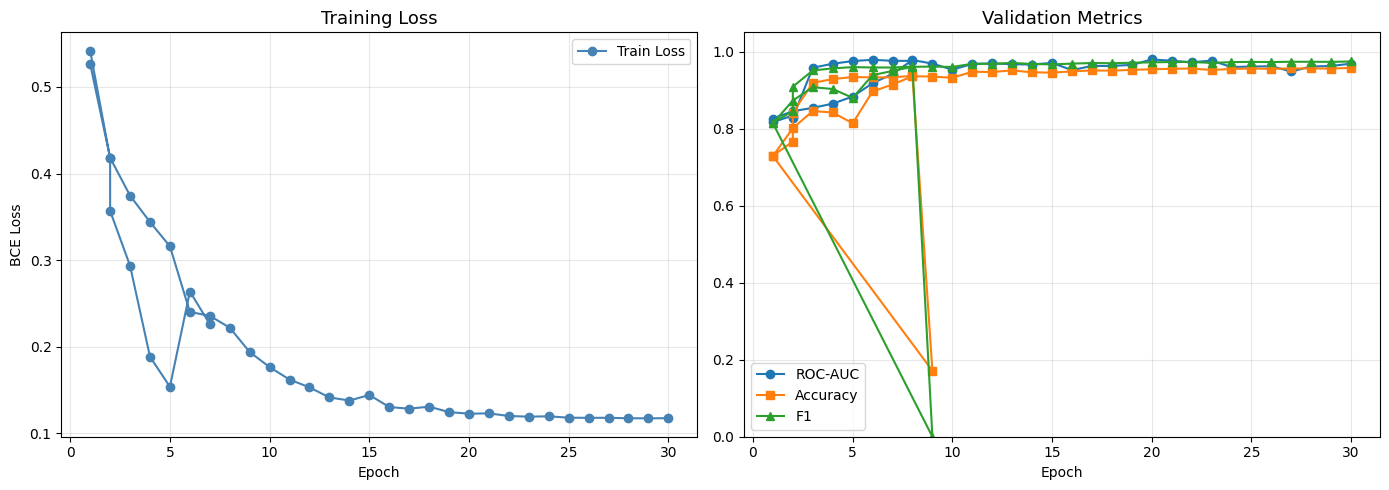

Best ROC-AUC : 0.9796
Best Accuracy: 0.9576


In [18]:
%matplotlib inline
import matplotlib.pyplot as plt

metrics_log = OUTPUT_DIR / 'cross_attention_v1' / 'metrics.jsonl'

if metrics_log.exists():
    metrics  = read_metrics_jsonl(metrics_log)
    eps      = [m['epoch']      for m in metrics]
    tl_vals  = [m['train_loss'] for m in metrics]
    val_auc  = [m.get('val',{}).get('roc_auc',  float('nan')) for m in metrics]
    val_acc  = [m.get('val',{}).get('accuracy', float('nan')) for m in metrics]
    val_f1   = [m.get('val',{}).get('f1',       float('nan')) for m in metrics]

    fig,axes=plt.subplots(1,2,figsize=(14,5))
    axes[0].plot(eps,tl_vals,marker='o',color='steelblue',label='Train Loss')
    axes[0].set_title('Training Loss',fontsize=13); axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('BCE Loss'); axes[0].grid(True,alpha=0.3); axes[0].legend()
    axes[1].plot(eps,val_auc,marker='o',label='ROC-AUC')
    axes[1].plot(eps,val_acc,marker='s',label='Accuracy')
    axes[1].plot(eps,val_f1, marker='^',label='F1')
    axes[1].set_title('Validation Metrics',fontsize=13); axes[1].set_xlabel('Epoch')
    axes[1].set_ylim(0,1.05); axes[1].grid(True,alpha=0.3); axes[1].legend()
    plt.tight_layout(); plt.show()

    valid_auc=[v for v in val_auc if not np.isnan(v)]
    valid_acc=[v for v in val_acc if not np.isnan(v)]
    if valid_auc:
        print(f'Best ROC-AUC : {max(valid_auc):.4f}')
        print(f'Best Accuracy: {max(valid_acc):.4f}')
else:
    print('No metrics log yet. Run training first.')

---
# Evaluation
> **Already trained?** Start from here. Make sure STEP 3 (paths) is run first.

## STEP 10 — Load Checkpoint for Evaluation

In [19]:
from pathlib import Path
device = get_device()

eval_cfg = dict(CONFIG['model'])
eval_cfg['pretrained'] = False
eval_model = build_model(eval_cfg).to(device)
if bool(CONFIG['training'].get('channels_last',True)):
    eval_model = eval_model.to(memory_format=torch.channels_last)

possible_checkpoints = [
    Path(CHECKPOINT_PATH),
    PROJECT_ROOT / 'best.pt',
    OUTPUT_DIR / 'cross_attention_v1' / 'last.pt',
]
actual_checkpoint = None
for p in possible_checkpoints:
    if p.exists():
        actual_checkpoint = p
        break

if actual_checkpoint is None:
    print('❌ Error: No checkpoint found!')
    print('👉 Make sure STEP 8 (Training) has run, or place best.pt in your Drive folder.')
else:
    print(f'Loading: {actual_checkpoint}')
    ckpt = load_model_checkpoint(str(actual_checkpoint), eval_model, map_location=device)
    eval_model.eval()
    ckpt_val = ckpt.get('metrics',{}).get('val',{}) if isinstance(ckpt.get('metrics'),dict) else {}
    print(f'\n✅ Model loaded successfully!')
    print(f'   Epoch   : {ckpt.get("epoch","?")}')
    print(f'   Val AUC : {ckpt_val.get("roc_auc","N/A")}')
    print(f'   Val Acc : {ckpt_val.get("accuracy","N/A")}')
    print(f'   Val F1  : {ckpt_val.get("f1","N/A")}')


2026-09-09 07:45:45,415 | INFO | Using GPU: Tesla T4
Using GPU: Tesla T4
CNN channels : 2048 | ViT dim : 768 | Heads : 8
Loading: /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/outputs/cross_attention_v1/best.pt

✅ Model loaded successfully!
   Epoch   : 30
   Val AUC : 0.96868836861075
   Val Acc : 0.9575722266013229
   Val F1  : 0.9742747901255091


## STEP 11 — Manifest Test Split Evaluation

2026-09-09 07:45:54,619 | INFO | ManifestImageDataset [test]: 29154 records
Evaluating test split: 29154 images



══════════════════════════════════════════════════  TEST SPLIT  ══════════════════════════════════════════════════
  Accuracy  : 95.44%
  Precision : 97.85%
  Recall    : 96.63%
  F1        : 97.23%
  ROC-AUC   : 0.9644
  TN=4480  FP=514  FN=814  TP=23346

  Fake Recall by Method:
    Deepfakes                     : 98.8%
    Face2Face                     : 97.6%
    FaceShifter                   : 98.7%
    FaceSwap                      : 98.7%
    NeuralTextures                : 89.2%
    generated_faceswap            : 98.5%


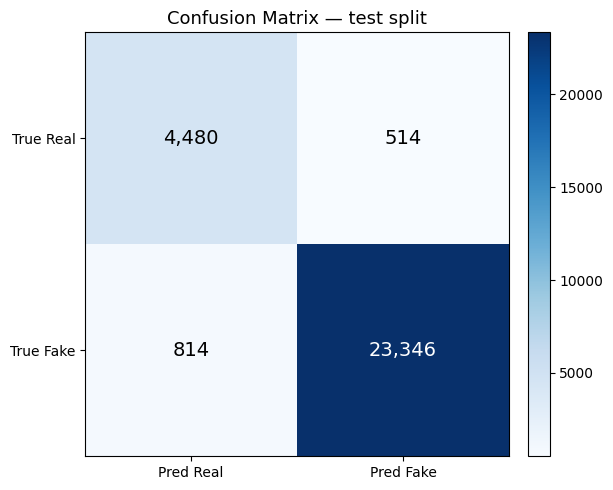

Saved to Drive: /content/drive/MyDrive/NEW_DATASET_DEEPFAKE/eval_results/metrics_test.json


In [20]:
%matplotlib inline
import matplotlib.pyplot as plt

EVAL_SPLIT = 'test'

isz    = int(CONFIG['training']['image_size'])
nw     = int(CONFIG['training'].get('num_workers',2))
root   = resolve_path(CONFIG['dataset']['archive_root']).parent
amp_en = bool(CONFIG['training'].get('amp',True)) and device.type=='cuda'
ch_last= bool(CONFIG['training'].get('channels_last',True))

eval_ds  = ManifestImageDataset(str(MANIFEST_PATH),EVAL_SPLIT,root,build_transforms(isz,'val'))
eval_ldr = DataLoader(eval_ds,batch_size=int(CONFIG['training']['batch_size']),shuffle=False,
                      num_workers=nw,pin_memory=torch.cuda.is_available(),persistent_workers=nw>0)

print(f'Evaluating {EVAL_SPLIT} split: {len(eval_ds)} images')
split_metrics=evaluate_model(eval_model,eval_ldr,device,amp_en,ch_last,f'Evaluating {EVAL_SPLIT}')

print(f'\n{"═"*50}  {EVAL_SPLIT.upper()} SPLIT  {"═"*50}')
print(f'  Accuracy  : {split_metrics["accuracy"]*100:.2f}%')
print(f'  Precision : {split_metrics["precision"]*100:.2f}%')
print(f'  Recall    : {split_metrics["recall"]*100:.2f}%')
print(f'  F1        : {split_metrics["f1"]*100:.2f}%')
print(f'  ROC-AUC   : {split_metrics["roc_auc"]:.4f}')
cm=split_metrics.get('confusion_matrix',{})
print(f'  TN={cm.get("tn",0)}  FP={cm.get("fp",0)}  FN={cm.get("fn",0)}  TP={cm.get("tp",0)}')
if 'fake_recall_by_method' in split_metrics:
    print('\n  Fake Recall by Method:')
    for method,recall in split_metrics['fake_recall_by_method'].items():
        print(f'    {method:<30}: {recall*100:.1f}%')

cm_v=np.array([[cm.get('tn',0),cm.get('fp',0)],[cm.get('fn',0),cm.get('tp',0)]],dtype=np.int64)
fig,ax=plt.subplots(figsize=(6,5))
im=ax.imshow(cm_v,cmap='Blues'); fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
ax.set_xticks([0,1],labels=['Pred Real','Pred Fake']); ax.set_yticks([0,1],labels=['True Real','True Fake'])
ax.set_title(f'Confusion Matrix — {EVAL_SPLIT} split',fontsize=13)
thr=cm_v.max()/2
for r in range(2):
    for c in range(2):
        ax.text(c,r,f'{cm_v[r,c]:,}',ha='center',va='center',fontsize=14,
                color='white' if cm_v[r,c]>thr else 'black')
plt.tight_layout(); plt.show()

EVAL_OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
with (EVAL_OUTPUT_DIR/f'metrics_{EVAL_SPLIT}.json').open('w',encoding='utf-8') as f:
    json.dump(split_metrics,f,indent=2)
print(f'Saved to Drive: {EVAL_OUTPUT_DIR}/metrics_{EVAL_SPLIT}.json')

## STEP 12 — Holdout Test + Faceswap Evaluation

In [ ]:
IMG_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}

def collect_labeled_images(root):
    root=Path(root); items=[]
    for cls,lbl in [('real',0),('fake',1)]:
        d=root/cls
        if d.exists():
            for p in sorted(d.rglob('*')):
                if p.is_file() and p.suffix.lower() in IMG_EXTS: items.append((p,lbl))
    return items

def crop_face_safe(path,margin,min_size):
    try:
        img=Image.open(path).convert('RGB'); crop=crop_largest_face(img,margin=margin,min_face_size=min_size)
        return path,crop.image,crop.crop_source
    except Exception as e: return path,None,f'error:{e}'

def evaluate_dataset_comprehensive(name,items,model,device,transform,face_margin,face_min_size):
    print(f'\n{"═"*60}'); print(f'  {name}  |  {len(items)} images'); print(f'{"═"*60}')
    if not items: print('  No images — skipping.'); return {},None,None
    t0=time.time(); paths=[p for p,_ in items]; labels=np.array([l for _,l in items])
    print(f'  Phase 1: Face detection ({FACE_WORKERS} threads)...')
    cropped={}
    with ThreadPoolExecutor(max_workers=FACE_WORKERS) as pool:
        futs={pool.submit(crop_face_safe,p,face_margin,face_min_size):p for p in paths}
        done=0
        for fut in as_completed(futs):
            p,img,_=fut.result()
            if img is not None: cropped[p]=img
            done+=1
            if done%2000==0: print(f'    {done}/{len(paths)}...')
    print(f'  Phase 1: {len(cropped)}/{len(paths)} cropped ({time.time()-t0:.1f}s)')
    print(f'  Phase 2: Inference (batch={BATCH_SIZE})...')
    t1=time.time(); vidx=[]; tlist=[]
    for i,(p,_) in enumerate(items):
        if p in cropped: tlist.append(transform(cropped[p])); vidx.append(i)
    preds=np.full(len(items),-1.0)
    model.eval()
    with torch.no_grad(),torch.amp.autocast(device_type=device.type,enabled=device.type=='cuda'):
        for st in range(0,len(tlist),BATCH_SIZE):
            batch=torch.stack(tlist[st:st+BATCH_SIZE]).to(device)
            # Standard sigmoid - no /7.0 hack; consistent with BCEWithLogitsLoss training
            probs=torch.sigmoid(model(batch)).cpu().float().numpy()
            for j,prob in enumerate(probs): preds[vidx[st+j]]=float(prob)
    print(f'  Phase 2 done ({time.time()-t1:.1f}s)')
    vm=preds>=0; vp=preds[vm]; vl=labels[vm]; pc=(vp>=THRESHOLD).astype(int)
    tp=int(((pc==1)&(vl==1)).sum()); tn=int(((pc==0)&(vl==0)).sum())
    fp=int(((pc==1)&(vl==0)).sum()); fn=int(((pc==0)&(vl==1)).sum())
    tot=tp+tn+fp+fn; acc=(tp+tn)/max(tot,1); prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1)
    f1=2*prec*rec/max(prec+rec,1e-8); skipped=int((~vm).sum())
    res={'dataset':name,'total':len(items),'evaluated':tot,'skipped':skipped,
         'accuracy':acc,'precision':prec,'recall':rec,'f1_score':f1,
         'confusion_matrix':{'TP':tp,'TN':tn,'FP':fp,'FN':fn},'threshold':THRESHOLD}
    print(f'  Acc={acc*100:.2f}%  Prec={prec*100:.2f}%  Rec={rec*100:.2f}%  F1={f1*100:.2f}%')
    return res,vl,pc

print('Comprehensive eval functions ready.')

In [ ]:
fcc      = CONFIG.get('inference',{}).get('face_crop',{})
face_mar = float(fcc.get('margin',0.35))
face_min = int(fcc.get('min_face_size',48))
val_tf   = build_transforms(int(CONFIG['training']['image_size']),'val')

holdout_items  = collect_labeled_images(HOLDOUT_DIR)
faceswap_items = collect_labeled_images(FACESWAP_DIR)
print(f'Holdout  : {len(holdout_items)} images  (from {HOLDOUT_DIR})')
print(f'Faceswap : {len(faceswap_items)} images  (from {FACESWAP_DIR})')

all_results=[]; lh=lf=ph=pf=None

if holdout_items:
    rh,lh,ph=evaluate_dataset_comprehensive('Holdout (Archive Test)',holdout_items,eval_model,device,val_tf,face_mar,face_min)
    if rh: all_results.append((rh,lh,ph))

if faceswap_items:
    rf,lf,pf=evaluate_dataset_comprehensive('Generated FaceSwap Test',faceswap_items,eval_model,device,val_tf,face_mar,face_min)
    if rf: all_results.append((rf,lf,pf))

if len(all_results)==2:
    cl=np.concatenate([lh,lf]); cp=np.concatenate([ph,pf])
    tp=int(((cp==1)&(cl==1)).sum()); tn=int(((cp==0)&(cl==0)).sum())
    fp=int(((cp==1)&(cl==0)).sum()); fn=int(((cp==0)&(cl==1)).sum())
    tot=tp+tn+fp+fn; acc=(tp+tn)/max(tot,1); prec=tp/max(tp+fp,1); rec=tp/max(tp+fn,1); f1=2*prec*rec/max(prec+rec,1e-8)
    combined={'dataset':'COMBINED','total':len(holdout_items)+len(faceswap_items),'evaluated':tot,
              'accuracy':acc,'precision':prec,'recall':rec,'f1_score':f1,
              'confusion_matrix':{'TP':tp,'TN':tn,'FP':fp,'FN':fn},'threshold':THRESHOLD}
    all_results.append((combined,cl,cp))
    print(f'\n  COMBINED: Acc={acc*100:.2f}%  Prec={prec*100:.2f}%  Rec={rec*100:.2f}%  F1={f1*100:.2f}%')

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

n=len(all_results)
if n>0:
    fig,axes=plt.subplots(1,n,figsize=(6*n,5))
    if n==1: axes=[axes]
    for ax,(res,_,__) in zip(axes,all_results):
        cm=res['confusion_matrix']
        mat=np.array([[cm['TN'],cm['FP']],[cm['FN'],cm['TP']]])
        pct=mat/np.maximum(mat.sum(axis=1,keepdims=True),1)*100
        im=ax.imshow(mat,cmap='Blues')
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Pred REAL','Pred FAKE'],fontsize=11)
        ax.set_yticklabels(['Actual REAL','Actual FAKE'],fontsize=11)
        ax.set_title(f"{res['dataset']}\nAcc={res['accuracy']*100:.1f}%  F1={res['f1_score']*100:.1f}%",
                     fontsize=12,fontweight='bold')
        for i in range(2):
            for j in range(2):
                color='white' if mat[i,j]>mat.max()*0.5 else 'black'
                ax.text(j,i,f'{mat[i,j]:,}\n({pct[i,j]:.1f}%)',ha='center',va='center',
                        fontsize=12,fontweight='bold',color=color)
        fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04)
    plt.tight_layout()
    EVAL_OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
    plt.savefig(EVAL_OUTPUT_DIR/'confusion_matrices.png',dpi=150,bbox_inches='tight'); plt.show()
    with (EVAL_OUTPUT_DIR/'comprehensive_eval_results.json').open('w',encoding='utf-8') as f:
        json.dump([r[0] for r in all_results],f,indent=2)
    print(f'Saved to Drive: {EVAL_OUTPUT_DIR}')

In [ ]:
# Per-method accuracy bar chart
%matplotlib inline
import matplotlib.pyplot as plt

if holdout_items and ph is not None:
    preds_h_full=np.array([float(ph[i]) if i<len(ph) else -1.0 for i in range(len(holdout_items))])
    method_res=defaultdict(lambda:{'correct':0,'total':0})
    for i,(path,label) in enumerate(holdout_items):
        if preds_h_full[i]<0: continue
        pred=1 if preds_h_full[i]>=THRESHOLD else 0; parts=path.parts
        if 'fake' in parts:
            fi=parts.index('fake'); method=parts[fi+1] if fi+1<len(parts) else 'unknown'
        elif 'real' in parts: method='real'
        else: method='unknown'
        method_res[method]['total']+=1
        if pred==label: method_res[method]['correct']+=1
    methods=sorted(method_res.keys())
    accs=[method_res[m]['correct']/max(method_res[m]['total'],1)*100 for m in methods]
    totals=[method_res[m]['total'] for m in methods]
    colors=['#2ecc71' if a>90 else '#e74c3c' if a<70 else '#f39c12' for a in accs]
    fig,ax=plt.subplots(figsize=(10,5))
    bars=ax.bar(range(len(methods)),accs,color=colors)
    ax.set_xticks(range(len(methods))); ax.set_xticklabels(methods,rotation=30,ha='right',fontsize=10)
    ax.set_ylabel('Accuracy (%)',fontsize=12)
    ax.set_title('Per-Method Accuracy — Holdout Test',fontsize=13,fontweight='bold')
    ax.set_ylim(0,108); ax.axhline(90,color='gray',linestyle='--',alpha=0.5,label='90% target')
    for bar,a,t in zip(bars,accs,totals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                f'{a:.1f}%\n(n={t})',ha='center',va='bottom',fontsize=9)
    ax.legend(); plt.tight_layout()
    plt.savefig(EVAL_OUTPUT_DIR/'per_method_accuracy.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'Saved to Drive: {EVAL_OUTPUT_DIR}/per_method_accuracy.png')

## STEP 13 — Single Image Prediction

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

# ╔══════════════════════════════════════════════════════════════╗
# ║  Set path to an image or a folder                           ║
IMAGE_TO_PREDICT = str(HOLDOUT_DIR / 'fake')   # example: entire fake folder
# ╚══════════════════════════════════════════════════════════════╝

def collect_image_paths(input_path):
    p=Path(input_path)
    if p.is_file(): return [p]
    if p.is_dir(): return sorted(q for q in p.rglob('*') if q.is_file() and q.suffix.lower() in IMG_EXTS)[:10]
    raise FileNotFoundError(f'Not found: {p}')

def overlay_label(image_path,prediction,confidence):
    img=Image.open(image_path).convert('RGB'); draw=ImageDraw.Draw(img)
    text=f'{prediction}  ({confidence:.1f}%)'; fsz=max(28,img.width//16)
    try: font=ImageFont.truetype('/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf',fsz)
    except OSError: font=ImageFont.load_default()
    bb=draw.textbbox((0,0),text,font=font); tw,th=bb[2]-bb[0],bb[3]-bb[1]
    bg=(220,38,38) if prediction=='FAKE' else (22,163,74)
    px,py=16,10; x0=(img.width-tw)//2-px; y0=12; x1=x0+tw+2*px; y1=y0+th+2*py
    ov=Image.new('RGBA',img.size,(0,0,0,0)); od=ImageDraw.Draw(ov)
    od.rounded_rectangle([x0,y0,x1,y1],radius=12,fill=(*bg,210))
    img=Image.alpha_composite(img.convert('RGBA'),ov).convert('RGB')
    ImageDraw.Draw(img).text((x0+px,y0+py),text,fill=(255,255,255),font=font)
    fig,ax=plt.subplots(figsize=(9,9)); ax.imshow(img); ax.axis('off')
    ax.set_title(Path(image_path).name,fontsize=13,fontweight='bold',pad=10)
    plt.tight_layout(); plt.show()

pred_tf  =build_transforms(int(CONFIG['training']['image_size']),'val')
face_mar2=float(CONFIG.get('inference',{}).get('face_crop',{}).get('margin',0.35))
face_min2=int(CONFIG.get('inference',{}).get('face_crop',{}).get('min_face_size',48))
amp_pred =bool(CONFIG['training'].get('amp',True)) and device.type=='cuda'
ch_pred  =bool(CONFIG['training'].get('channels_last',True))

if not Path(IMAGE_TO_PREDICT).exists():
    print(f'❌ Not found: {IMAGE_TO_PREDICT}')
else:
    for img_path in collect_image_paths(IMAGE_TO_PREDICT):
        with Image.open(img_path) as raw: raw=raw.convert('RGB')
        face_crops=crop_all_faces(raw,margin=face_mar2,min_face_size=face_min2,fallback_to_full_image=True)
        tensors=[pred_tf(fc.image) for fc in face_crops]
        t=torch.stack(tensors).to(device)
        if ch_pred: t=t.contiguous(memory_format=torch.channels_last)
        with torch.inference_mode(),torch.amp.autocast(device_type=device.type,enabled=amp_pred):
            logits=eval_model(t)
        # Standard sigmoid - no /7.0 hack
        probs=torch.sigmoid(logits).detach().float().cpu().tolist()
        best_prob=max(probs); prediction='FAKE' if best_prob>=0.5 else 'REAL'
        confidence=max(best_prob,1.0-best_prob)*100
        print(f'  {img_path.name}  →  {prediction}  ({confidence:.1f}%)')
        overlay_label(img_path,prediction,confidence)